# EXPERIMENT - 02: Spam Email Detection (Simple Q&A)

## Q1) Load dataset and do EDA
**Answer:** Load `spambase.data`, show first 10 rows, shape, missing values, duplicates, class distribution chart.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Spambase has 57 features + class
cols = [f'f{i}' for i in range(57)] + ['class']
df = pd.read_csv('spambase.data', header=None, names=cols)

print('Shape:', df.shape)
print('First 10 rows:')
df.head(10)

Shape: (4601, 58)
First 10 rows:


,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,...,f48,f49,f50,f51,f52,f53,f54,f55,f56,class
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1
5,0.00,0.00,0.00,0.0,1.85,0.00,0.00,1.85,0.00,0.00,...,0.00,0.223,0.0,0.000,0.000,0.000,3.000,15,54,1
6,0.00,0.00,0.00,0.0,1.92,0.00,0.00,0.00,0.00,0.64,...,0.00,0.054,0.0,0.164,0.054,0.000,1.671,4,112,1
7,0.00,0.00,0.00,0.0,1.88,0.00,0.00,1.88,0.00,0.00,...,0.00,0.206,0.0,0.000,0.000,0.000,2.450,11,49,1
8,0.15,0.00,0.46,0.0,0.61,0.00,0.30,0.00,0.92,0.76,...,0.00,0.271,0.0,0.181,0.203,0.022,9.744,445,1257,1
9,0.06,0.12,0.77,0.0,0.19,0.32,0.38,0.00,0.06,0.00,...,0.04,0.030,0.0,0.244,0.081,0.000,1.729,43,749,1


Missing values: 0
Duplicate rows: 391
Class counts (0=Not Spam, 1=Spam):
class
0    2788
1    1813
Name: count, dtype: int64


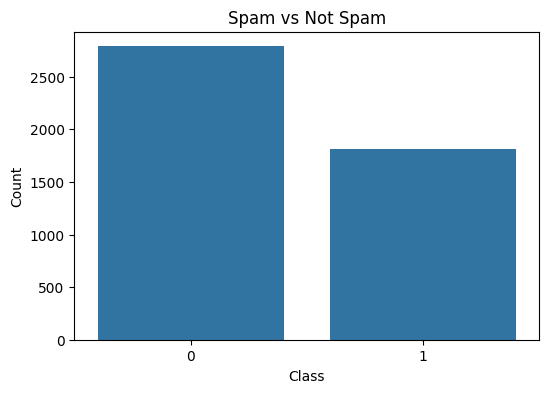

In [2]:
print('Missing values:', int(df.isna().sum().sum()))
print('Duplicate rows:', int(df.duplicated().sum()))

counts = df['class'].value_counts().sort_index()
print('Class counts (0=Not Spam, 1=Spam):')
print(counts)

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='class')
plt.title('Spam vs Not Spam')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

## Q2) Build Naive Bayes model
**Answer:** Use GaussianNB with train/test split (75:25).

In [3]:
X = df.drop(columns=['class'])
y = df['class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

model = GaussianNB()
model.fit(X_train, y_train)
pred = model.predict(X_test)

## Q3) Evaluate model: Accuracy, Precision, Recall, F1, confusion matrix
**Answer:** Also inspect FP/FN and comment on class imbalance impact.

Accuracy : 0.8306
Precision: 0.7133
Recall   : 0.9537
F1-score : 0.8162
Confusion Matrix: [[523 174]
 [ 21 433]]
Classification Report:               precision    recall  f1-score   support

           0       0.96      0.75      0.84       697
           1       0.71      0.95      0.82       454

    accuracy                           0.83      1151
   macro avg       0.84      0.85      0.83      1151
weighted avg       0.86      0.83      0.83      1151



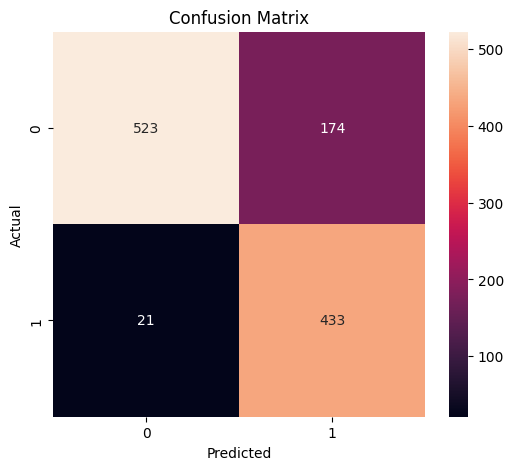

False Positives: 174
False Negatives: 21


In [8]:
acc = accuracy_score(y_test, pred)
prec = precision_score(y_test, pred)
rec = recall_score(y_test, pred)
f1 = f1_score(y_test, pred)

print('Accuracy :', round(acc,4))
print('Precision:', round(prec,4))
print('Recall   :', round(rec,4))
print('F1-score :', round(f1,4))

cm = confusion_matrix(y_test, pred)
print('Confusion Matrix:', cm)
print('Classification Report:', classification_report(y_test, pred))

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

fp = cm[0][1]
fn = cm[1][0]
print('False Positives:', fp)
print('False Negatives:', fn)

### Final note
- FP: legitimate emails marked as spam.
- FN: spam emails missed.
- If class imbalance exists, precision/recall/F1 are more informative than only accuracy.